
Federated Learning Experiment: FedDAAW vs FedAvg vs FedProx

Loading CIFAR-10 data...
Original training set shape: (50000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)

Performing Non-IID data partitioning...
[Non-IID Partition Complete] Total samples: 50000
Client data sizes -> min: 100, max: 5000, mean: 2500.0

Starting federated learning training...
Global epochs: 22, Clients selected per round: 17
Local training epochs: 1, Batch size: 30
FedProx mu: 0.01

Global Epoch 1/22

[FedDAAW Method]
DA selected clients: [5, 13, 4, 14, 17, 16, 1, 7, 8, 12, 3, 19, 10, 2, 9, 15, 6]
DA aggregation weights: [0.07191662 0.05211349 0.06878981 0.02605675 0.02895194 0.01737116
 0.09484655 0.08876665 0.06079907 0.02518819 0.0880718  0.06687898
 0.04516503 0.07886508 0.05697742 0.06948466 0.0597568 ]

[FedAvg Method]
FedAvg selected clients: [8, 9, 2, 10, 19, 0, 3, 18, 13, 11, 14, 12, 15, 5, 6, 4, 16]

[FedProx Method]
FedProx selected clients: [16, 2, 8, 4, 14, 12, 0, 7, 3, 18, 1, 19, 9, 11, 6, 15,

DA aggregation weights: [0.07114263 0.06273167 0.06011966 0.05159082 0.03629515 0.05149568
 0.07250551 0.07145285 0.07632322 0.05300126 0.04665633 0.05970397
 0.04274073 0.06701677 0.05170249 0.0670023  0.05851895]

[FedAvg Method]
FedAvg selected clients: [5, 15, 6, 7, 16, 9, 13, 4, 0, 1, 18, 17, 14, 12, 2, 11, 19]

[FedProx Method]
FedProx selected clients: [7, 17, 5, 8, 3, 13, 15, 16, 9, 4, 1, 0, 6, 18, 19, 12, 14]

Epoch 7 Results:
  FedDAAW Accuracy: 0.2061
  FedAvg Accuracy: 0.2428
  FedProx Accuracy: 0.2485

Global Epoch 8/22

[FedDAAW Method]
DA selected clients: [2, 7, 15, 19, 9, 4, 10, 6, 13, 5, 1, 12, 14, 16, 3, 8, 17]
DA aggregation weights: [0.05798617 0.06697598 0.07300992 0.06093129 0.0619671  0.06793588
 0.04991435 0.05296855 0.0522879  0.06685382 0.07516473 0.0488672
 0.04136259 0.06265473 0.06511903 0.05469636 0.04130442]

[FedAvg Method]
FedAvg selected clients: [19, 6, 3, 18, 17, 10, 7, 13, 14, 0, 4, 2, 5, 11, 9, 1, 16]

[FedProx Method]
FedProx selected clients: [1


[FedAvg Method]
FedAvg selected clients: [1, 10, 5, 8, 2, 4, 15, 18, 6, 19, 9, 17, 14, 16, 12, 3, 13]

[FedProx Method]
FedProx selected clients: [13, 16, 9, 2, 12, 8, 15, 17, 14, 11, 1, 10, 5, 7, 0, 4, 3]

Epoch 18 Results:
  FedDAAW Accuracy: 0.3455
  FedAvg Accuracy: 0.2965
  FedProx Accuracy: 0.3065

Global Epoch 19/22

[FedDAAW Method]
DA selected clients: [0, 16, 5, 17, 13, 1, 4, 15, 10, 2, 3, 8, 14, 12, 19, 6, 7]
DA aggregation weights: [0.07631867 0.06383195 0.06816712 0.05312671 0.05396878 0.06763913
 0.06387129 0.05445846 0.0506476  0.05635713 0.06837487 0.0514909
 0.05129298 0.0493015  0.05905454 0.04816685 0.06393153]

[FedAvg Method]
FedAvg selected clients: [2, 15, 0, 10, 7, 3, 14, 18, 16, 11, 5, 9, 1, 12, 19, 6, 13]

[FedProx Method]
FedProx selected clients: [12, 14, 17, 15, 18, 11, 7, 16, 2, 9, 13, 8, 10, 5, 19, 1, 6]

Epoch 19 Results:
  FedDAAW Accuracy: 0.3436
  FedAvg Accuracy: 0.3029
  FedProx Accuracy: 0.3004

Global Epoch 20/22

[FedDAAW Method]
DA selected cli

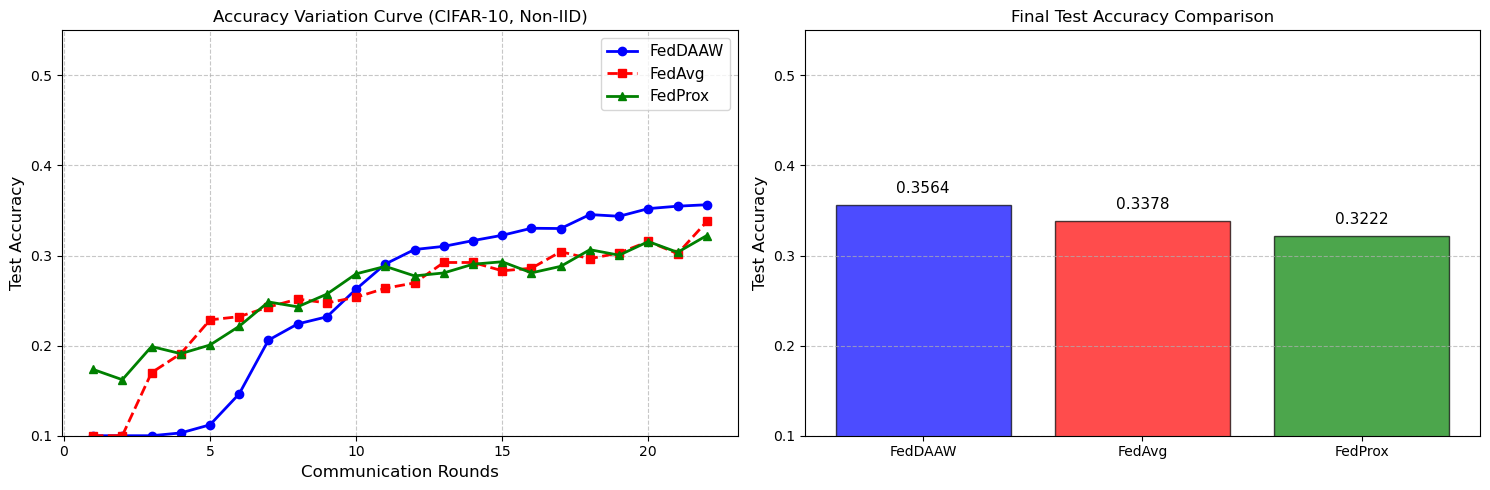


Final Experimental Results (Three-way Comparison)
FedDAAW Final Accuracy: 0.3564
FedAvg Final Accuracy: 0.3378
FedProx Final Accuracy: 0.3222

----------------------------------------
Improvement Analysis:
FedDAAW vs FedAvg: +0.0186 (1.86%)
FedDAAW vs FedProx: +0.0342 (3.42%)

----------------------------------------
Convergence Analysis (threshold = 0.25):
  FedDAAW reaches 0.25 at round: 10
  FedAvg reaches 0.25 at round: 8
  FedProx reaches 0.25 at round: 9


In [2]:
"""
Federated Learning Comparison: FedDAAW vs FedAvg vs FedProx
Dataset: CIFAR-10 (Non-IID distribution)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from scipy import stats
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import SGD
from tensorflow.keras import layers, models

# ============================================================
# 1. 全局参数配置
# ============================================================

# 总客户端数量
NUM_CLIENTS = 20
# 类别数
NUM_CLASSES = 10
# 图片输入形状
IMAGE_SHAPE = (32, 32, 3)
# 历史趋势窗口大小
WINDOW_SIZE = 3
# 客户端选择评分权重
WEIGHT_HISTORY = 0.6
WEIGHT_DATA = 0.3
WEIGHT_SYS = 0.1
# 每轮选择的客户端数量
NUM_SELECT_CLIENTS = 17
# 自适应聚合平滑系数
LAMBDA_SMOOTH = 0.9
# 本地训练轮数
LOCAL_EPOCHS = 1
# 学习率
LEARNING_RATE = 0.01
# 批大小
BATCH_SIZE = 30
# 全局通信轮数
NUM_GLOBAL_EPOCHS = 22
# FedProx近端项系数
FEDPROX_MU = 0.01

# 固定随机种子确保可复现
tf.random.set_seed(42)
np.random.seed(42)


# ============================================================
# 2. 工具函数
# ============================================================

def normalize_scores(scores):
    """将分数归一化到[0, 1]范围"""
    if len(scores) == 0:
        return np.array([])
    min_score = np.min(scores)
    max_score = np.max(scores)
    if max_score - min_score < 1e-6:
        return np.ones_like(scores) / len(scores)
    return (scores - min_score) / (max_score - min_score)


def build_model():
    """构建CNN模型"""
    model = tf.keras.models.Sequential([
        layers.InputLayer(input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# ============================================================
# 3. 数据加载与Non-IID划分
# ============================================================

def load_and_partition_data_non_iid(
    x_train_original,
    y_train_original,
    num_clients=10,
    client_ratios=None,
    alpha=0.5,
    val_ratio=0.3
):
    """
    使用Dirichlet分布将数据非独立同分布地划分给多个客户端
    """
    x_data = x_train_original
    y_data = y_train_original

    total_samples = len(x_data)

    if client_ratios is None:
        client_ratios = [1.0 / num_clients] * num_clients
    else:
        assert len(client_ratios) == num_clients, "Length of client_ratios must equal num_clients"
        assert abs(sum(client_ratios) - 1.0) < 1e-6, "Sum of client_ratios must be 1.0"

    client_sizes = [int(ratio * total_samples) for ratio in client_ratios]
    diff = total_samples - sum(client_sizes)
    for i in range(diff):
        client_sizes[i] += 1

    class_indices = [np.where(y_data == i)[0] for i in range(NUM_CLASSES)]
    used_mask = np.zeros(total_samples, dtype=bool)

    client_data = []

    for i in range(num_clients):
        needed = client_sizes[i]
        class_probs = np.random.dirichlet([alpha] * NUM_CLASSES)

        selected_indices = []
        remaining = needed

        class_order = np.random.permutation(NUM_CLASSES)
        for class_id in class_order:
            n_from_class = int(class_probs[class_id] * needed)
            if n_from_class == 0 and remaining > 0:
                n_from_class = 1

            if n_from_class > remaining:
                n_from_class = remaining

            available_indices = class_indices[class_id][~used_mask[class_indices[class_id]]]
            n_available = len(available_indices)
            if n_available <= n_from_class:
                selected = available_indices
            else:
                selected = np.random.choice(available_indices, size=n_from_class, replace=False)

            selected_indices.extend(selected)
            used_mask[selected] = True
            remaining -= len(selected)

            if remaining <= 0:
                break

        if remaining > 0:
            all_remaining = np.where(~used_mask)[0]
            if len(all_remaining) < remaining:
                selected = all_remaining
            else:
                selected = np.random.choice(all_remaining, size=remaining, replace=False)
            selected_indices.extend(selected)
            used_mask[selected] = True

        assert len(selected_indices) == needed, f"Client {i} sample count error"

        selected_indices = np.array(selected_indices)
        np.random.shuffle(selected_indices)

        X_local = x_data[selected_indices]
        y_local = y_data[selected_indices]

        X_local = X_local.reshape(-1, 32, 32, 3).astype('float32') / 255.0

        split = int((1 - val_ratio) * len(X_local))
        client_data.append({
            'X_train': X_local[:split],
            'y_train': y_local[:split],
            'X_val': X_local[split:],
            'y_val': y_local[split:],
            'class_probs': class_probs
        })

    actual_sizes = [len(d['X_train']) + len(d['X_val']) for d in client_data]
    print(f"[Non-IID Partition Complete] Total samples: {total_samples}")
    print(f"Client data sizes -> min: {min(actual_sizes)}, max: {max(actual_sizes)}, mean: {np.mean(actual_sizes):.1f}")

    return client_data


# ============================================================
# 4. 基础客户端类 (用于FedAvg和FedDAAW)
# ============================================================

class Client:
    def __init__(self, client_id, data_dict):
        self.client_id = client_id
        self.X_train = data_dict['X_train']
        self.y_train = data_dict['y_train']
        self.X_val = data_dict['X_val']
        self.y_val = data_dict['y_val']
        self.model = build_model()
        self.acc_history = []
        self.acc_trend = 0.0
        self.data_similarity = 0.0
        self.sys_score = np.random.uniform(0.7, 1.0)

    def local_train(self, global_weights):
        """使用全局权重进行本地训练"""
        self.model.set_weights(global_weights)
        self.model.fit(
            self.X_train,
            self.y_train,
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0,
            validation_data=(self.X_val, self.y_val)
        )
        return self.model.get_weights()

    def local_evaluate(self):
        """在本地验证集上评估模型"""
        y_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        acc = accuracy_score(self.y_val, y_pred)
        self.acc_history.append(acc)

        hist = self.acc_history
        if len(hist) >= WINDOW_SIZE:
            x = np.arange(WINDOW_SIZE)
            slope, _, _, _, _ = stats.linregress(x, hist[-WINDOW_SIZE:])
            self.acc_trend = slope
        elif len(hist) >= 2:
            x = np.arange(len(hist))
            slope, _, _, _, _ = stats.linregress(x, hist)
            self.acc_trend = slope
        else:
            self.acc_trend = 0.0

        return acc

    def get_historical_performance_factor(self):
        return max(0, self.acc_trend) + 0.1

    def get_data_quality_factor(self):
        return max(0.1, min(1.0, self.data_similarity))

    def get_system_factor(self):
        return self.sys_score


# ============================================================
# 5. FedProx客户端类 (带近端项)
# ============================================================

class FedProxClient(Client):
    """
    FedProx客户端：在本地训练中增加近端项约束
    近端项：μ/2 * ||w - w_global||²
    """
    def __init__(self, client_id, data_dict, mu=0.01):
        super().__init__(client_id, data_dict)
        self.mu = mu
        self.global_weights = None

    def local_train(self, global_weights):
        """
        执行带近端项的本地训练
        """
        self.global_weights = [w.copy() for w in global_weights]
        self.model.set_weights(global_weights)

        optimizer = tf.keras.optimizers.SGD(learning_rate=LEARNING_RATE)

        train_dataset = tf.data.Dataset.from_tensor_slices((self.X_train, self.y_train))
        train_dataset = train_dataset.shuffle(buffer_size=len(self.X_train)).batch(BATCH_SIZE)

        for epoch in range(LOCAL_EPOCHS):
            for batch_x, batch_y in train_dataset:
                with tf.GradientTape() as tape:
                    predictions = self.model(batch_x, training=True)
                    loss = tf.keras.losses.sparse_categorical_crossentropy(batch_y, predictions)
                    loss = tf.reduce_mean(loss)

                    # FedProx近端项
                    proximal_loss = 0.0
                    for local_w, global_w in zip(self.model.trainable_weights, self.global_weights):
                        proximal_loss += tf.reduce_sum(tf.square(local_w - global_w))
                    proximal_loss = (self.mu / 2.0) * proximal_loss

                    total_loss = loss + proximal_loss

                grads = tape.gradient(total_loss, self.model.trainable_weights)
                optimizer.apply_gradients(zip(grads, self.model.trainable_weights))

        return self.model.get_weights()


# ============================================================
# 6. 服务器: FedDAAW
# ============================================================

class ServerDA:
    def __init__(self):
        self.global_model = build_model()
        self.global_weights = self.global_model.get_weights()
        self.global_acc_history = []

    def calculate_selection_score(self, clients):
        """计算客户端选择分数"""
        scores = []
        for c in clients:
            hist_factor = c.get_historical_performance_factor()
            data_factor = c.get_data_quality_factor()
            sys_factor = c.get_system_factor()

            score = (WEIGHT_HISTORY * hist_factor +
                     WEIGHT_DATA * data_factor +
                     WEIGHT_SYS * sys_factor)
            scores.append(score)

        return np.array(scores)

    def select_clients(self, clients):
        """基于分数选择客户端"""
        scores = self.calculate_selection_score(clients)
        probs = normalize_scores(scores)
        probs = probs / probs.sum()

        if np.any(np.isnan(probs)) or np.all(probs == 0):
            probs = np.ones(len(clients)) / len(clients)

        indices = np.random.choice(
            len(clients),
            size=min(NUM_SELECT_CLIENTS, len(clients)),
            replace=False,
            p=probs
        )

        selected = [clients[i] for i in indices]
        print(f"DA selected clients: {[c.client_id for c in selected]}")
        return selected

    def calculate_adaptive_weights(self, selected_clients):
        """计算自适应聚合权重"""
        weights = []
        for c in selected_clients:
            if len(c.acc_history) == 0:
                weights.append(0.1)
            else:
                current = c.acc_history[-1]
                avg = np.mean(c.acc_history) if len(c.acc_history) > 0 else current
                smoothed = LAMBDA_SMOOTH * current + (1 - LAMBDA_SMOOTH) * avg
                weights.append(smoothed)

        weights = np.array(weights)
        if np.sum(weights) > 0:
            weights = weights / np.sum(weights)
        else:
            weights = np.ones(len(weights)) / len(weights)

        return weights

    def update_data_similarity(self, selected_clients, client_weights_list):
        """更新数据相似度（基于第一层权重的余弦相似度）"""
        if len(selected_clients) == 0:
            return

        global_first_layer = self.global_weights[0].flatten()
        global_norm = np.linalg.norm(global_first_layer)

        for i, (c, cw) in enumerate(zip(selected_clients, client_weights_list)):
            client_first_layer = cw[0].flatten()
            client_norm = np.linalg.norm(client_first_layer)

            if global_norm > 1e-8 and client_norm > 1e-8:
                similarity = np.dot(global_first_layer, client_first_layer) / (global_norm * client_norm)
                c.data_similarity = max(0, min(1, similarity))
            else:
                c.data_similarity = 0.5

    def aggregate(self, selected_clients, client_weights_list):
        """聚合客户端模型"""
        if len(selected_clients) == 0:
            return

        adaptive_w = self.calculate_adaptive_weights(selected_clients)
        print(f"DA aggregation weights: {adaptive_w}")

        new_weights = []
        for layer_idx in range(len(self.global_weights)):
            weighted_sum = np.zeros_like(self.global_weights[layer_idx])
            for alpha, cw in zip(adaptive_w, client_weights_list):
                weighted_sum += alpha * cw[layer_idx]
            new_weights.append(weighted_sum)

        self.global_weights = new_weights
        self.update_data_similarity(selected_clients, client_weights_list)

    def evaluate(self, test_data=None, test_labels=None):
        """评估全局模型"""
        if test_data is None:
            test_data = x_test_cnn
            test_labels = y_test_categorical

        self.global_model.set_weights(self.global_weights)
        y_pred = np.argmax(self.global_model.predict(test_data, verbose=0), axis=1)

        if test_labels.ndim > 1:
            y_true = np.argmax(test_labels, axis=1)
        else:
            y_true = test_labels

        acc = accuracy_score(y_true, y_pred)
        self.global_acc_history.append(acc)

        return acc


# ============================================================
# 7. 服务器: FedAvg (基线)
# ============================================================

class ServerFedAvg:
    def __init__(self):
        self.global_model = build_model()
        self.global_weights = self.global_model.get_weights()
        self.global_acc_history = []

    def select_clients(self, clients):
        """随机选择客户端"""
        indices = np.random.choice(
            len(clients),
            size=min(NUM_SELECT_CLIENTS, len(clients)),
            replace=False
        )
        selected = [clients[i] for i in indices]
        print(f"FedAvg selected clients: {[c.client_id for c in selected]}")
        return selected

    def aggregate(self, client_weights_list):
        """FedAvg聚合：简单平均"""
        if len(client_weights_list) == 0:
            return

        new_weights = []
        for layer_idx in range(len(self.global_weights)):
            avg_layer = np.zeros_like(self.global_weights[layer_idx])
            for cw in client_weights_list:
                avg_layer += cw[layer_idx]
            avg_layer = avg_layer / len(client_weights_list)
            new_weights.append(avg_layer)

        self.global_weights = new_weights

    def evaluate(self, test_data=None, test_labels=None):
        """评估全局模型"""
        if test_data is None:
            test_data = x_test_cnn
            test_labels = y_test_categorical

        self.global_model.set_weights(self.global_weights)
        y_pred = np.argmax(self.global_model.predict(test_data, verbose=0), axis=1)

        if test_labels.ndim > 1:
            y_true = np.argmax(test_labels, axis=1)
        else:
            y_true = test_labels

        acc = accuracy_score(y_true, y_pred)
        self.global_acc_history.append(acc)

        return acc


# ============================================================
# 8. 服务器: FedProx
# ============================================================

class ServerFedProx:
    def __init__(self):
        self.global_model = build_model()
        self.global_weights = self.global_model.get_weights()
        self.global_acc_history = []

    def select_clients(self, clients):
        """随机选择客户端（与FedAvg相同）"""
        indices = np.random.choice(
            len(clients),
            size=min(NUM_SELECT_CLIENTS, len(clients)),
            replace=False
        )
        selected = [clients[i] for i in indices]
        print(f"FedProx selected clients: {[c.client_id for c in selected]}")
        return selected

    def aggregate(self, client_weights_list):
        """FedProx聚合：简单平均（与FedAvg相同）"""
        if len(client_weights_list) == 0:
            return

        new_weights = []
        for layer_idx in range(len(self.global_weights)):
            avg_layer = np.zeros_like(self.global_weights[layer_idx])
            for cw in client_weights_list:
                avg_layer += cw[layer_idx]
            avg_layer = avg_layer / len(client_weights_list)
            new_weights.append(avg_layer)

        self.global_weights = new_weights

    def evaluate(self, test_data=None, test_labels=None):
        """评估全局模型"""
        if test_data is None:
            test_data = x_test_cnn
            test_labels = y_test_categorical

        self.global_model.set_weights(self.global_weights)
        y_pred = np.argmax(self.global_model.predict(test_data, verbose=0), axis=1)

        if test_labels.ndim > 1:
            y_true = np.argmax(test_labels, axis=1)
        else:
            y_true = test_labels

        acc = accuracy_score(y_true, y_pred)
        self.global_acc_history.append(acc)

        return acc


# ============================================================
# 9. 主训练函数 (三路对比)
# ============================================================

da_accuracies = []
fedavg_accuracies = []
fedprox_accuracies = []


def main():
    global da_accuracies, fedavg_accuracies, fedprox_accuracies

    print("\n" + "="*60)
    print("Federated Learning Experiment: FedDAAW vs FedAvg vs FedProx")
    print("="*60)

    # 加载CIFAR-10数据
    print("\nLoading CIFAR-10 data...")
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

    global x_test_cnn, y_test_categorical
    x_test_cnn = x_test.reshape(-1, 32, 32, 3).astype('float32') / 255.0
    y_test_categorical = tf.keras.utils.to_categorical(y_test, 10)

    print(f"Original training set shape: {x_train.shape}")
    print(f"Test set shape: {x_test_cnn.shape}")

    # Non-IID数据划分
    print("\nPerforming Non-IID data partitioning...")
    fixed_ratios = [0.1, 0.1, 0.1, 0.1, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1,
                    0.005, 0.005, 0.02, 0.03, 0.002, 0.003, 0.002, 0.003, 0.04, 0.04]

    client_datasets = load_and_partition_data_non_iid(
        x_train,
        y_train,
        num_clients=NUM_CLIENTS,
        alpha=0.5,
        client_ratios=fixed_ratios,
        val_ratio=0.2
    )

    # 创建三组客户端（相同数据，独立模型）
    clients_da = [Client(i, client_datasets[i]) for i in range(NUM_CLIENTS)]
    clients_fedavg = [Client(i, client_datasets[i]) for i in range(NUM_CLIENTS)]
    clients_fedprox = [FedProxClient(i, client_datasets[i], mu=FEDPROX_MU) for i in range(NUM_CLIENTS)]

    # 初始化服务器
    server_da = ServerDA()
    server_fedavg = ServerFedAvg()
    server_fedprox = ServerFedProx()

    print(f"\nStarting federated learning training...")
    print(f"Global epochs: {NUM_GLOBAL_EPOCHS}, Clients selected per round: {NUM_SELECT_CLIENTS}")
    print(f"Local training epochs: {LOCAL_EPOCHS}, Batch size: {BATCH_SIZE}")
    print(f"FedProx mu: {FEDPROX_MU}")

    for epoch in range(NUM_GLOBAL_EPOCHS):
        print(f"\n{'='*50}")
        print(f"Global Epoch {epoch+1}/{NUM_GLOBAL_EPOCHS}")
        print(f"{'='*50}")

        # ========== 1. FedDAAW ==========
        print("\n[FedDAAW Method]")
        selected_da = server_da.select_clients(clients_da)

        weights_da = []
        for client in selected_da:
            client_weights = client.local_train(server_da.global_weights)
            weights_da.append(client_weights)

        for client in selected_da:
            client.local_evaluate()

        server_da.aggregate(selected_da, weights_da)
        acc_da = server_da.evaluate()
        da_accuracies.append(acc_da)

        # ========== 2. FedAvg ==========
        print("\n[FedAvg Method]")
        selected_fed = server_fedavg.select_clients(clients_fedavg)

        weights_fed = []
        for client in selected_fed:
            client_weights = client.local_train(server_fedavg.global_weights)
            weights_fed.append(client_weights)

        for client in selected_fed:
            client.local_evaluate()

        server_fedavg.aggregate(weights_fed)
        acc_fed = server_fedavg.evaluate()
        fedavg_accuracies.append(acc_fed)

        # ========== 3. FedProx ==========
        print("\n[FedProx Method]")
        selected_prox = server_fedprox.select_clients(clients_fedprox)

        weights_prox = []
        for client in selected_prox:
            client_weights = client.local_train(server_fedprox.global_weights)
            weights_prox.append(client_weights)

        for client in selected_prox:
            client.local_evaluate()

        server_fedprox.aggregate(weights_prox)
        acc_prox = server_fedprox.evaluate()
        fedprox_accuracies.append(acc_prox)

        print(f"\nEpoch {epoch+1} Results:")
        print(f"  FedDAAW Accuracy: {acc_da:.4f}")
        print(f"  FedAvg Accuracy: {acc_fed:.4f}")
        print(f"  FedProx Accuracy: {acc_prox:.4f}")

        # Early stopping（三种方法都连续3轮不提升时停止）
        if epoch >= 3:
            if (da_accuracies[-1] <= da_accuracies[-2] <= da_accuracies[-3] and
                fedavg_accuracies[-1] <= fedavg_accuracies[-2] <= fedavg_accuracies[-3] and
                fedprox_accuracies[-1] <= fedprox_accuracies[-2] <= fedprox_accuracies[-3]):
                print("\nConvergence detected, early stopping training")
                break


# ============================================================
# 10. 可视化与结果输出
# ============================================================

def plot_results():
    """绘制三路对比结果"""
    epochs_trained = len(da_accuracies)

    if epochs_trained == 0:
        print("No training data available. Please run main() first.")
        return

    plt.figure(figsize=(15, 5))

    # 子图1: 准确率曲线
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs_trained + 1), da_accuracies, 'b-o', linewidth=2, markersize=6, label='FedDAAW')
    plt.plot(range(1, epochs_trained + 1), fedavg_accuracies, 'r--s', linewidth=2, markersize=6, label='FedAvg')
    plt.plot(range(1, epochs_trained + 1), fedprox_accuracies, 'g-^', linewidth=2, markersize=6, label='FedProx')
    plt.xlabel('Communication Rounds', fontsize=12)
    plt.ylabel('Test Accuracy', fontsize=12)
    plt.title('Accuracy Variation Curve (CIFAR-10, Non-IID)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.ylim([0.1, 0.55])

    # 子图2: 最终准确率对比
    plt.subplot(1, 2, 2)
    methods = ['FedDAAW', 'FedAvg', 'FedProx']
    final_accs = [da_accuracies[-1], fedavg_accuracies[-1], fedprox_accuracies[-1]]
    colors = ['blue', 'red', 'green']

    bars = plt.bar(methods, final_accs, color=colors, alpha=0.7, edgecolor='black')
    plt.ylabel('Test Accuracy', fontsize=12)
    plt.title('Final Test Accuracy Comparison', fontsize=12)
    plt.ylim([0.1, 0.55])

    for bar, acc in zip(bars, final_accs):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{acc:.4f}', ha='center', va='bottom', fontsize=11)

    plt.grid(True, linestyle='--', alpha=0.7, axis='y')

    plt.tight_layout()
    plt.show()

    # ========== 打印最终结果 ==========
    print("\n" + "="*60)
    print("Final Experimental Results (Three-way Comparison)")
    print("="*60)
    print(f"FedDAAW Final Accuracy: {da_accuracies[-1]:.4f}")
    print(f"FedAvg Final Accuracy: {fedavg_accuracies[-1]:.4f}")
    print(f"FedProx Final Accuracy: {fedprox_accuracies[-1]:.4f}")

    print("\n" + "-"*40)
    print("Improvement Analysis:")
    improvement_da_vs_avg = da_accuracies[-1] - fedavg_accuracies[-1]
    improvement_da_vs_prox = da_accuracies[-1] - fedprox_accuracies[-1]
    print(f"FedDAAW vs FedAvg: +{improvement_da_vs_avg:.4f} ({improvement_da_vs_avg*100:.2f}%)")
    print(f"FedDAAW vs FedProx: +{improvement_da_vs_prox:.4f} ({improvement_da_vs_prox*100:.2f}%)")

    # 收敛速度分析（达到25%准确率所需的轮数）
    threshold = 0.25
    da_threshold_idx = next((i for i, acc in enumerate(da_accuracies) if acc >= threshold), None)
    fedavg_threshold_idx = next((i for i, acc in enumerate(fedavg_accuracies) if acc >= threshold), None)
    fedprox_threshold_idx = next((i for i, acc in enumerate(fedprox_accuracies) if acc >= threshold), None)

    print("\n" + "-"*40)
    print(f"Convergence Analysis (threshold = {threshold}):")
    print(f"  FedDAAW reaches {threshold} at round: {da_threshold_idx + 1 if da_threshold_idx is not None else 'N/A'}")
    print(f"  FedAvg reaches {threshold} at round: {fedavg_threshold_idx + 1 if fedavg_threshold_idx is not None else 'N/A'}")
    print(f"  FedProx reaches {threshold} at round: {fedprox_threshold_idx + 1 if fedprox_threshold_idx is not None else 'N/A'}")


# ============================================================
# 11. 程序入口
# ============================================================

if __name__ == "__main__":
    main()
    plot_results()